# Desafio: Classificação de Gêneros Cinematográficos com Catboost

## 🎯 Objetivo
Neste desafio, você irá desenvolver um modelo preditivo capaz de identificar os gêneros de um filme (ação, comédia e romance) com base em suas características estruturais e criativas.

O desafio consiste em aplicar um modelo de classificação multirrótulo utilizando o algoritmo CatBoostClassifier, treinado a partir de um dataset sintético com 2000 filmes.

## 📁 Dataset: movies.csv
Cada linha representa um filme, com informações como duração, elenco, estilo musical, quantidade de explosões, entre outros. Os filmes podem pertencer a mais de um gênero ao mesmo tempo.

### Features

| Coluna               | Tipo       | Descrição                                         |
| -------------------- | ---------- | ------------------------------------------------- |
| `duration_minutes`   | Numérico   | Duração do filme em minutos                       |
| `cast_count`         | Numérico   | Quantidade de membros no elenco                   |
| `has_superstars`     | Binário    | 1 se há estrelas conhecidas no elenco             |
| `explosions_count`   | Numérico   | Quantidade de cenas com explosões                 |
| `music_style`        | Categórico | Tipo da trilha sonora (`orchestral`, `pop`, etc.) |
| `director_fame`      | Categórico | Fama do diretor (`low`, `medium`, `high`)         |
| `dialogue_density`   | Numérico   | Número médio de falas por minuto                  |
| `has_romantic_scene` | Binário    | 1 se o filme contém cenas românticas              |
| `humor_level`        | Numérico   | Nível de humor (0 a 10)                           |
| `violence_level`     | Numérico   | Nível de violência (0 a 10)                       |

### Targets

| Coluna       | Tipo    | Descrição                  |
| ------------ | ------- | -------------------------- |
| `is_action`  | Binário | 1 se é um filme de ação    |
| `is_comedy`  | Binário | 1 se é um filme de comédia |
| `is_romance` | Binário | 1 se é um filme de romance |



# Carregar Dados e Imports

In [15]:
# EDA
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, ttest_ind
from colorama import Fore, Back, Style

# Visualização
import plotly.express as px
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Configurar visualização dos dados
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True, precision=3)

# ML
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix, \
                            ConfusionMatrixDisplay, log_loss, roc_curve, roc_auc_score

# Interpretabilidade
import shap

In [16]:
df_filmes = pd.read_csv('datasets/movies.csv')

In [17]:
# Visualizar a estrutura
df_filmes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   duration_minutes    2000 non-null   int64  
 1   cast_count          2000 non-null   int64  
 2   has_superstars      2000 non-null   int64  
 3   explosions_count    2000 non-null   int64  
 4   music_style         2000 non-null   object 
 5   director_fame       2000 non-null   object 
 6   dialogue_density    2000 non-null   float64
 7   has_romantic_scene  2000 non-null   int64  
 8   humor_level         2000 non-null   float64
 9   violence_level      2000 non-null   float64
 10  is_comedy           2000 non-null   int64  
 11  is_action           2000 non-null   int64  
 12  is_romance          2000 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 203.3+ KB


In [18]:
df_filmes.head(10)

,duration_minutes,cast_count,has_superstars,explosions_count,music_style,director_fame,dialogue_density,has_romantic_scene,humor_level,violence_level,is_comedy,is_action,is_romance
0,131,3,0,4,pop,low,5.390,0,5.980,8.080,0,1,0
1,172,9,0,0,electronic,low,2.880,1,3.680,1.910,0,0,0
2,94,12,0,2,pop,medium,3.170,1,7.050,8.470,1,1,1
3,151,14,1,2,acoustic,medium,2.640,1,7.410,0.580,1,0,0
4,140,18,1,0,jazz,medium,4.540,0,6.970,0.060,0,0,0
5,100,9,1,2,orchestral,low,5.600,1,9.370,1.580,1,0,1
6,162,19,1,1,electronic,low,3.730,1,2.370,9.790,0,1,1
7,166,19,0,1,pop,medium,1.390,1,1.890,5.240,0,0,0
8,154,15,1,4,jazz,medium,2.120,1,6.100,0.470,0,0,0
9,154,16,1,3,pop,low,4.160,1,5.950,9.970,0,1,1


In [19]:
df_filmes.tail(10)

,duration_minutes,cast_count,has_superstars,explosions_count,music_style,director_fame,dialogue_density,has_romantic_scene,humor_level,violence_level,is_comedy,is_action,is_romance
1990,173,18,1,0,pop,medium,4.050,0,5.340,9.270,0,1,0
1991,157,12,0,1,electronic,low,3.350,1,7.500,4.870,1,0,1
1992,150,11,1,1,orchestral,low,1.750,0,2.960,5.670,0,0,0
1993,96,18,1,0,electronic,low,2.290,0,7.580,2.570,1,0,0
1994,163,5,0,1,acoustic,medium,1.220,0,6.690,5.140,0,0,0
1995,179,17,0,3,orchestral,medium,3.620,0,7.280,7.480,1,1,0
1996,88,16,1,2,electronic,high,3.720,0,9.480,4.920,1,0,0
1997,117,6,0,0,acoustic,medium,2.070,0,4.250,3.020,0,0,0
1998,127,7,1,3,pop,medium,5.300,0,3.430,5.820,0,0,0
1999,139,18,1,3,acoustic,medium,5.440,0,6.840,9.470,0,1,0


In [20]:
# Valores possíveis para variáveis categoricas
for col in df_filmes.select_dtypes(include=['object']).columns:
    print(f'\nValores únicos em {col}:')
    print(df_filmes[col].unique())


Valores únicos em music_style:
['pop' 'electronic' 'acoustic' 'jazz' 'orchestral']

Valores únicos em director_fame:
['low' 'medium' 'high']


In [21]:
# Verificar se tem valores nulo
df_filmes.isnull().sum()

duration_minutes      0
cast_count            0
has_superstars        0
explosions_count      0
music_style           0
director_fame         0
dialogue_density      0
has_romantic_scene    0
humor_level           0
violence_level        0
is_comedy             0
is_action             0
is_romance            0
dtype: int64

# EDA

In [22]:
targets = ['is_comedy', 'is_action', 'is_romance']

In [23]:
features_numericas = df_filmes.drop(columns=targets, axis=1).select_dtypes(include=['float64', 'int64']).columns
features_numericas

Index(['duration_minutes', 'cast_count', 'has_superstars', 'explosions_count',
       'dialogue_density', 'has_romantic_scene', 'humor_level',
       'violence_level'],
      dtype='object')

In [24]:
features_categoricas = df_filmes.select_dtypes(include=['object']).columns
features_categoricas

Index(['music_style', 'director_fame'], dtype='object')

### Visualizar Distribuição dos targets

In [ ]:
for col in targets:
    df_count = df_filmes[col].value_counts().reset_index()
    df_count.columns = ['categoria', 'contagem']
    fig = px.bar(df_count,
                 x='categoria',
                 y='contagem',
                 title=f'Distribuição / Contagem de {col}')
    fig.show()

### Visualizar a distribuição das features numéricas

In [ ]:
for col in features_numericas:
    fig = px.histogram(df_filmes, x=col, nbins=20, title=f'Distribuição de {col}')
    fig.show()

### Contagem de valores para variáveis categóricas

In [ ]:
for col in features_categoricas:
    df_count = df_filmes[col].value_counts().reset_index()
    df_count.columns = ['categoria', 'contagem']
    fig = px.bar(df_count,
                 x='categoria',
                 y='contagem',
                 title=f'Distribuição / Contagem de {col}')
    fig.show()

In [27]:
# Visualizar Distribuição dos targets
for col in targets:
    df_count = df_empresas[col].value_counts().reset_index()
    df_count.columns = ['categoria', 'contagem']
    fig = px.bar(df_count,
                 x='categoria',
                 y='contagem',
                 title=f'Distribuição / Contagem de {col}')
    fig.show()

### Analisar relação entre features numericas e targets


In [29]:
for target in targets:
    for col in features_numericas:
        fig = px.box(df_filmes, x=target, y=col, title=f'{col} por {target}')
        fig.show()

### Analisar relação entre features categoricas e targets

In [30]:
for target in targets:
    for col in features_categoricas:
        fig = px.histogram(df_filmes, x=col, color=target, barmode='group', title=f'{col} por {target}')
        fig.show()

### Matriz de Correlação


In [32]:
correlation_matrix = df_filmes[features_numericas.tolist() + targets].corr()

# Heatmap da matriz de correlação
fig = px.imshow(correlation_matrix,
                color_continuous_scale='armyrose',
                title='Matriz de Correlação',
                zmin=-1,
                zmax=1
)

# Ajustes no Heatmap
fig.update_traces(text=correlation_matrix, texttemplate='%{text:.1%}', textfont=dict(size=9))

fig.update_layout(
    width=1500,
    height=800,
    title_font=dict(size=20),
    font=dict(size=14)
)

fig.show()

# Preparação dos dados

In [33]:
# Separar X e y
X = df_filmes.drop(columns=targets, axis=1)
y = df_filmes[targets]

In [34]:
# Separar entre Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=51, shuffle=True)

# Treinamento do Modelo Catboost com abordagem OnevsRest (OnevsAll)

In [35]:
# Criar o objeto Catboost
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    cat_features=features_categoricas.tolist(),
    random_strength=2,
    loss_function='Logloss'
)

In [36]:
# Colocar o modelo Catboost na abordagem OneVsRest
ovr_model = OneVsRestClassifier(cat_model)

In [37]:
# Treinar o modelo
ovr_model.fit(X_train, y_train)

0:	learn: 0.6156083	total: 53.1ms	remaining: 53s
1:	learn: 0.5219384	total: 57.2ms	remaining: 28.6s
2:	learn: 0.4488972	total: 59.4ms	remaining: 19.8s
3:	learn: 0.4034958	total: 62.2ms	remaining: 15.5s
4:	learn: 0.3676629	total: 63.7ms	remaining: 12.7s
5:	learn: 0.3252589	total: 66.7ms	remaining: 11s
6:	learn: 0.2880404	total: 68.5ms	remaining: 9.72s
7:	learn: 0.2512712	total: 71ms	remaining: 8.8s
8:	learn: 0.2201087	total: 73.2ms	remaining: 8.06s
9:	learn: 0.2087806	total: 74.5ms	remaining: 7.38s
10:	learn: 0.1912627	total: 77.1ms	remaining: 6.93s
11:	learn: 0.1785856	total: 79.3ms	remaining: 6.53s
12:	learn: 0.1631750	total: 82.4ms	remaining: 6.26s
13:	learn: 0.1537717	total: 85.7ms	remaining: 6.04s
14:	learn: 0.1463315	total: 87.8ms	remaining: 5.77s
15:	learn: 0.1384521	total: 89.2ms	remaining: 5.49s
16:	learn: 0.1321401	total: 90.2ms	remaining: 5.22s
17:	learn: 0.1285501	total: 92ms	remaining: 5.02s
18:	learn: 0.1237075	total: 94ms	remaining: 4.85s
19:	learn: 0.1203194	total: 95.3m

OneVsRestClassifier(estimator=<catboost.core.CatBoostClassifier object at 0x7586ffd7a3c0>)

## Análise dos Resultados e métricas

In [38]:
# Fazer predição das classes com base no modelo
y_pred = ovr_model.predict(X_test)

In [39]:
# Fazer a predição das probabilidades com base no modelo
y_pred_proba = ovr_model.predict_proba(X_test)

In [40]:
# Relatório de Classificação
print('Relatório de Classificação')
print(classification_report(y_test, y_pred, zero_division=0))

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       287
           1       0.88      1.00      0.93       253
           2       0.81      0.95      0.87       183

   micro avg       0.86      0.98      0.92       723
   macro avg       0.86      0.98      0.91       723
weighted avg       0.86      0.98      0.92       723
 samples avg       0.53      0.55      0.54       723




Matriz de Confusão para is_comedy


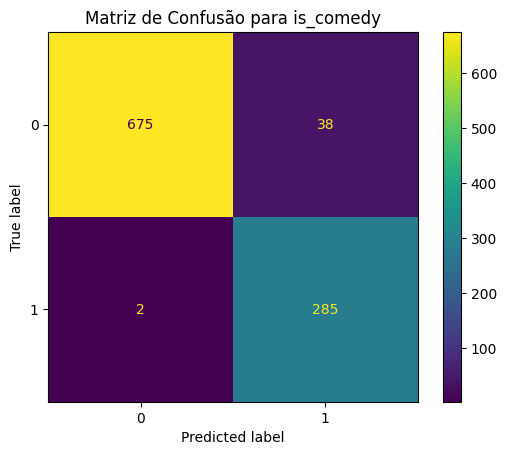


Matriz de Confusão para is_action


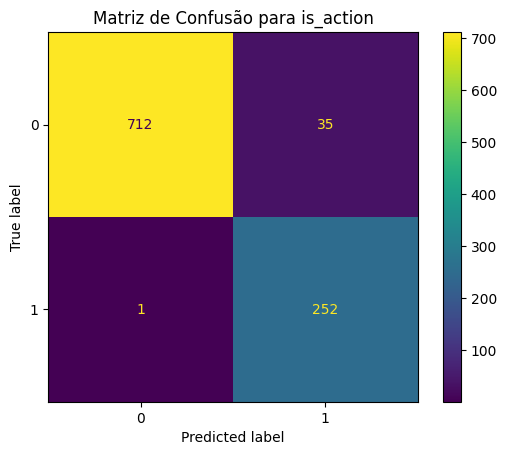


Matriz de Confusão para is_romance


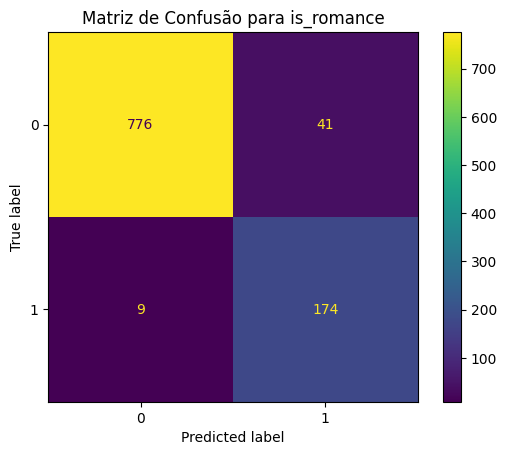

In [41]:
# Mostrar a matriz de confusão para cada classe
for i, target in enumerate(targets):
    print(f'\nMatriz de Confusão para {target}')
    conf_matrix = confusion_matrix(y_test.iloc[:, i], y_pred[:, i])
    fig = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
    fig.plot()
    plt.title(f'Matriz de Confusão para {target}')
    plt.show()

In [42]:
# Calcular o logloss para cada target
print('Log Loss por Target')
for i, target in enumerate(targets):
    log_loss_score = log_loss(y_test.iloc[:, i], y_pred_proba[:, i])
    print(f'{target}: {log_loss_score:.4f}')

Log Loss por Target
is_comedy: 0.1619
is_action: 0.1772
is_romance: 0.1696


## Interpretabilidade

In [43]:
# Importância das features - Para cada target

for i, target in enumerate(targets):

    # Obter a importância das features
    importancias = ovr_model.estimators_[i].feature_importances_
    nomes_features = X.columns.tolist()

    # Criar um Dataframe com as importâncias e nomes de features
    df_importancias = pd.DataFrame({'feature': nomes_features, 'importancia': importancias})

    # Ordenar o Dataframe
    df_importancias = df_importancias.sort_values('importancia', ascending=False).reset_index(drop=True)

    # Montar o Plot
    fig = px.bar(
        df_importancias.head(10),
        x='importancia',
        y='feature',
        orientation='h',
        title=f'Importância das 10 principais features - {target}',
        labels={'importancia': 'Importância', 'feature': 'Feature'},
        color='importancia',
        color_continuous_scale='ArmyRose'
    )

    # Personalizar o layout
    fig.update_layout(
        height=600,
        yaxis={'categoryorder': 'total ascending'}
    )

    fig.show()

#### Visualizar exemplo de árvore

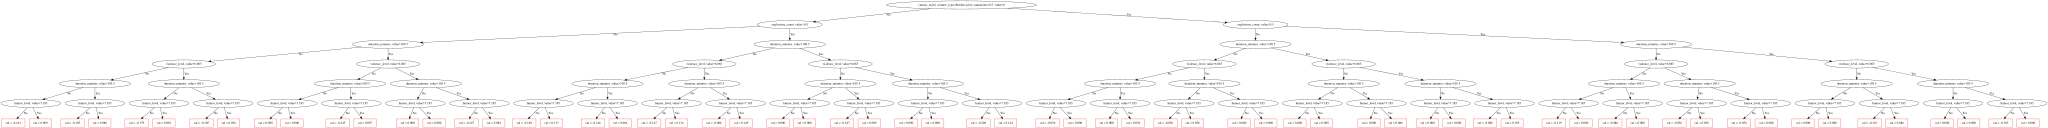

In [ ]:

modelo_catboost = ovr_model.estimators_[0]

# Criar o Pool com os dados de treinamento
pool = Pool(
    data=X_train,
    label=y_train.iloc[:, 2],
    cat_features=features_categoricas.tolist(),
    feature_names=list(X_train.columns)
)

# Plotar a árvore
modelo_catboost.plot_tree(tree_idx=0, pool=pool)

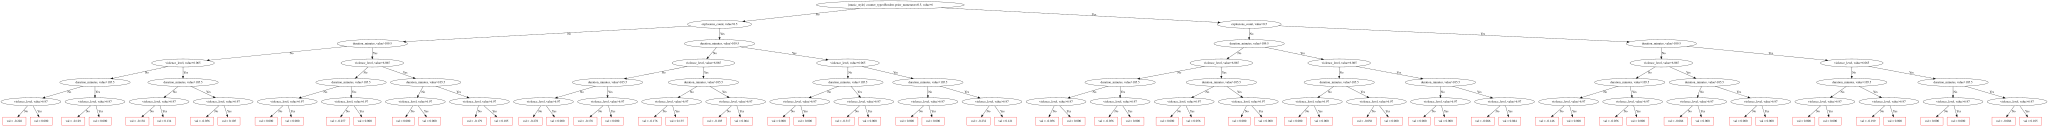

In [45]:
# Visualizar exemplo de árvore
modelo_catboost = ovr_model.estimators_[1]

# Criar o Pool com os dados de treinamento
pool = Pool(
    data=X_train,
    label=y_train.iloc[:, 2],
    cat_features=features_categoricas.tolist(),
    feature_names=list(X_train.columns)
)

# Plotar a árvore
modelo_catboost.plot_tree(tree_idx=0, pool=pool)

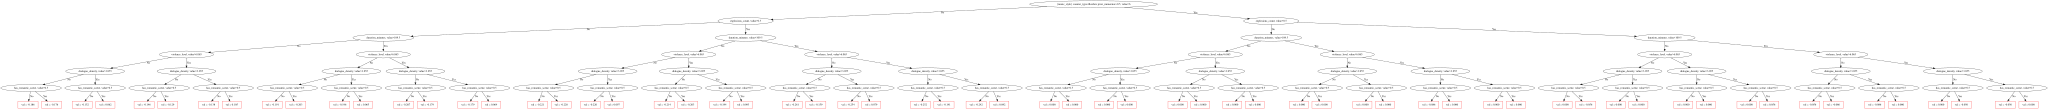

In [46]:
# Visualizar exemplo de árvore
modelo_catboost = ovr_model.estimators_[2]

# Criar o Pool com os dados de treinamento
pool = Pool(
    data=X_train,
    label=y_train.iloc[:, 2],
    cat_features=features_categoricas.tolist(),
    feature_names=list(X_train.columns)
)

# Plotar a árvore
modelo_catboost.plot_tree(tree_idx=0, pool=pool)

In [47]:
# Shap Values

# Criar e rodar explainers para cada target
explainers = []
shap_values = []

for i, target in enumerate(targets):
    print(f'Calculando SHAP values para {target}...')

    # Usar TreeExplainer específico pra Catboost
    explainer = shap.TreeExplainer(ovr_model.estimators_[i])

    # Calcular valores SHAP
    shap_values_target = explainer.shap_values(X_test)

    # Atualizo as listas
    explainers.append(explainer)
    shap_values.append(shap_values_target)

Calculando SHAP values para is_comedy...
Calculando SHAP values para is_action...
Calculando SHAP values para is_romance...



Gráfico SHAP para is_comedy:


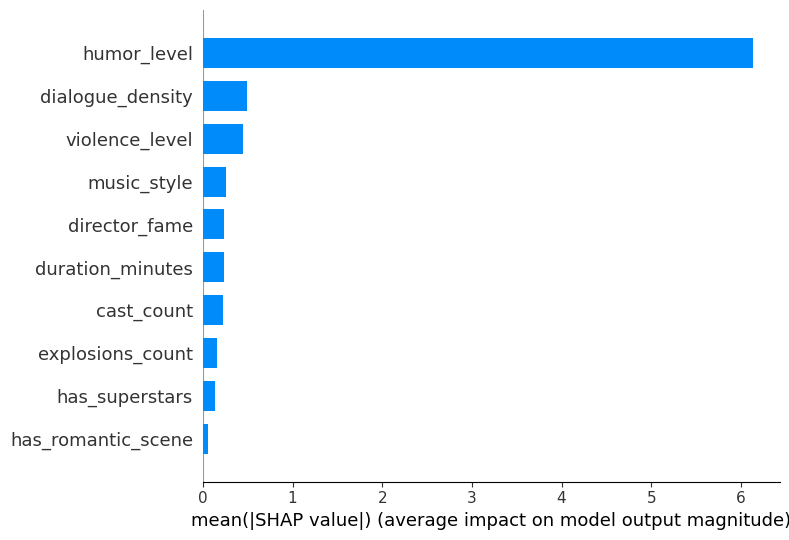

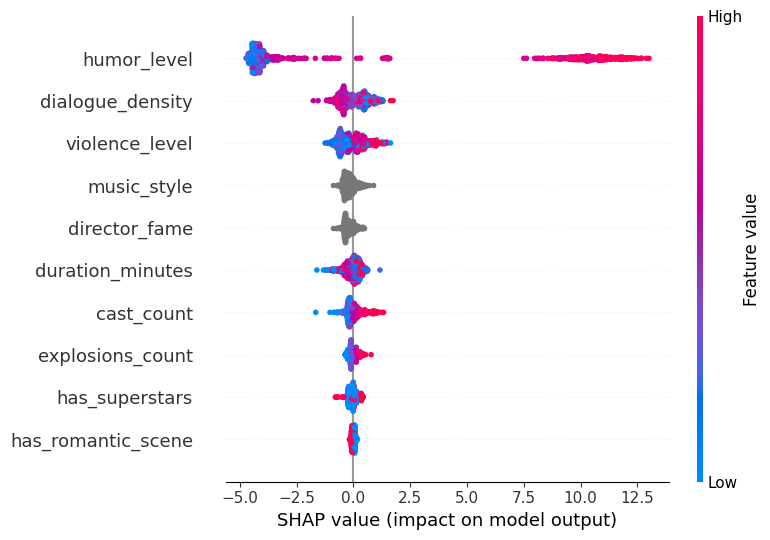


Gráfico SHAP para is_action:


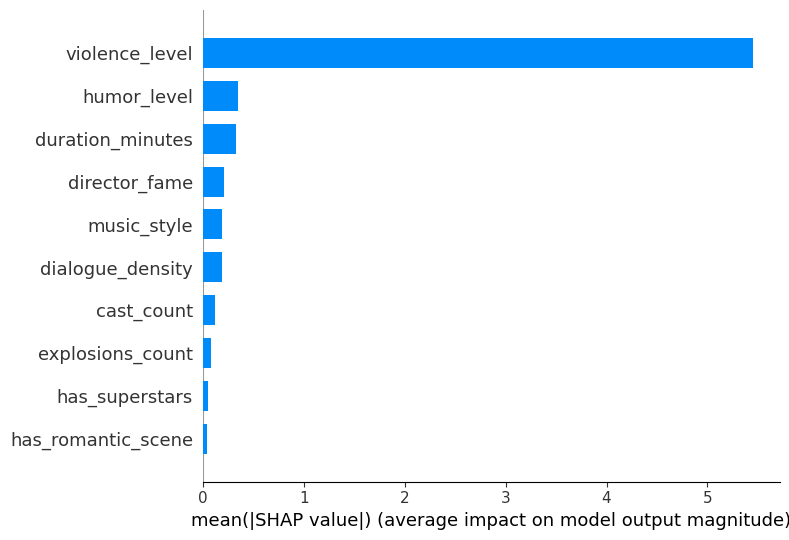

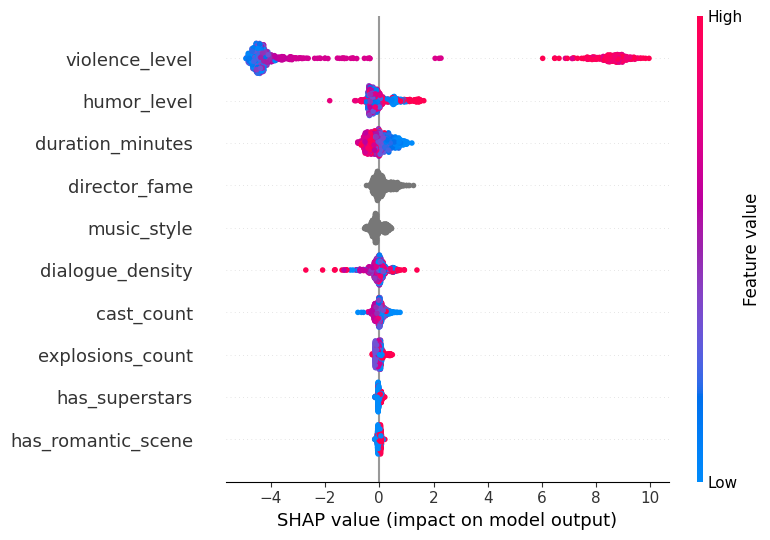


Gráfico SHAP para is_romance:


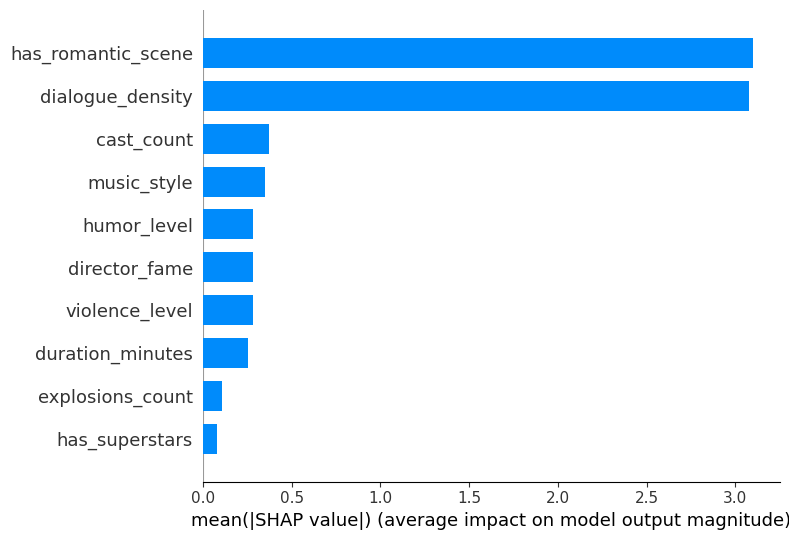

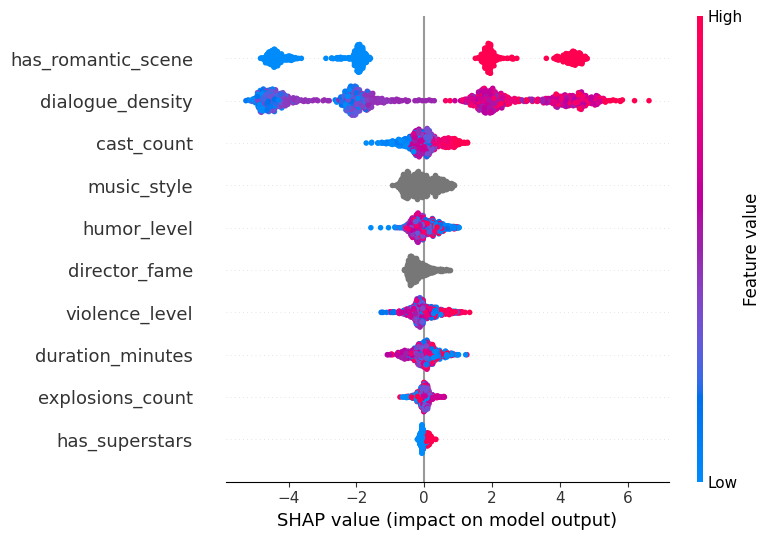

In [48]:
# Plotar gráficos SHAP para cada target

for i, target in enumerate(targets):
    print(f'\nGráfico SHAP para {target}:')

    # Criar o gráfico de resumo de SHAP
    shap.summary_plot(
        shap_values[i],
        X_test,
        plot_type='bar',
        title=f'Contribuição Global das Variáveis - {target}',
        show=False
    )
    plt.tight_layout()
    plt.show()

    # Criar o gráfico de resumo de SHAP
    shap.summary_plot(
        shap_values[i],
        X_test,
        title=f'Distribuição dos Valores SHAP - {target}',
        show=False
    )
    plt.tight_layout()
    plt.show()

